In [16]:
import feos
from feos import EquationOfState, Parameters, PhaseDiagram
import si_units as si
import numpy as np
import pandas as pd
from si_units import *
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_context('poster')
sns.set_palette('Dark2')
sns.set_style('ticks')
colors = sns.palettes.color_palette('Dark2', 8)

## Compare SAFT-VRQ-Mie, $uv$-CS-theory and SAFT-VR-CS for Hydrogen

In [2]:
tc = 5.1953
rho_c = 17.4 * MOL / LITER * 4.002602 * GRAM /MOL / (KILOGRAM/METER**3)
vle = pd.read_csv("data/hydrogen_data/nist_vle.txt", sep="\t")
#vle = vle[vle['Temperature (K)'] < 0.9 * tc][11:]
#isotherms = pd.read_csv("data/hydrogen_data//nist_isotherms.txt", sep="\t")

### SAFT-VRQ-Mie with FH1 Parameters of Aasen

In [22]:
#ailo = dict(sigma=2.7443, epsilon_k=5.4195, rep=9, att=6, c_sigma=[1.0]*3, c_epsilon_k=[1.0]*3, c_rep=[1.0]*5)
 #9 
vrqmie_ailo = dict(m=1.0, sigma=3.0243, epsilon_k= 26.706, lr=9, la=6, fh=1)
vrq_pr = feos.PureRecord(identifier=feos.Identifier("Hydrogen"), molarweight=2.016, **vrqmie_ailo)
vrq_model = EquationOfState.saftvrqmie(Parameters.new_pure(vrq_pr))

#vle_vrq = PhaseDiagram.pure(vrq_model, 2.5*KELVIN, 100)
df_vrq = PhaseDiagram.pure(vrq_model, min_temperature=14*si.KELVIN, npoints=250).to_dict(feos.Contributions.Residual)

### $uv$-CS with optimized parameters of van Westen

In [23]:
# uv-CS with optimized parameters
# uv-CS with optimized parameters
thijs = dict(
    sigma=3.0156,
    epsilon_k=23.8730,
    rep=8.101,
    att=6.0,
    c_sigma= [1.43832767e+00, 6.45545710e-04, 1.50887940e+00], 
    c_epsilon_k=[1.0, 1.0, 1.0],
    c_rep=[2.76585117e-01, 1.78562579e+01, 1.82868514e+02, 1.26035205e-04, 2.88248756e+01]
)
#pr = feos.PureRecord(identifier=feos.Identifier("helium"), molarweight=4.002602, **thijs)
pr = feos.PureRecord(identifier=feos.Identifier("hydrogen"), molarweight=2.016, **thijs)
cs_model = feos.EquationOfState.uvcstheory(feos.Parameters.new_pure(pr))
df_cs = feos.PhaseDiagram.pure(cs_model, min_temperature=14*si.KELVIN, npoints=250).to_dict(feos.Contributions.Residual)

### SAFT-VR-CS with optimized parameters of this work
- classical parameters from Aasen FH1

In [24]:
# SAFT-VR-CS
ailo = dict(m=1.0,  sigma=2.7443, epsilon_k=5.4195, lr=9, la=6,
            c_sigma= [0.4489, -1.4309, 0.3800], #[0.7652,1.444,0.7686], 
            c_epsilon_k=  [0.8008, -0.1291, 1.2354], #[1.1293,-0.5168,1.1744],
            c_lr=[0.8435, 1.0865, 0.7571, 1.5142, 1.3214])# [0.8719,1.2691,1.6244,1.4737,0.6102])


ailo = dict(m=1.0, sigma=3.0243, epsilon_k= 26.706, lr=9, la=6)

#[{"":0,"coefficient":"c_sigma","values":[0.7652,1.444,0.7686]},{"":1,"coefficient":"c_epsilon_k","values":[1.1293,-0.5168,1.1744]},{"":2,"coefficient":"c_lr","values":[0.8719,1.2691,1.6244,1.4737,0.6102]}]
vrcs_pr = feos.PureRecord(identifier=feos.Identifier("helium"), molarweight=2.016, **ailo)
vrcs_model = EquationOfState.saftvrcs_mie(Parameters.new_pure(vrcs_pr))

#vle_vrq = PhaseDiagram.pure(vrq_model, 2.5*KELVIN, 100)
df_vrcs = PhaseDiagram.pure(vrcs_model, min_temperature=14*si.KELVIN, npoints=250).to_dict(feos.Contributions.Residual)

### Reproduce FIG. 4 of J. Chem. Phys. 162, 031101 (2025); doi: 10.1063/5.0243474

In [25]:
#isotherms = isotherms.loc[isotherms['Pressure (MPa)'] < 5]

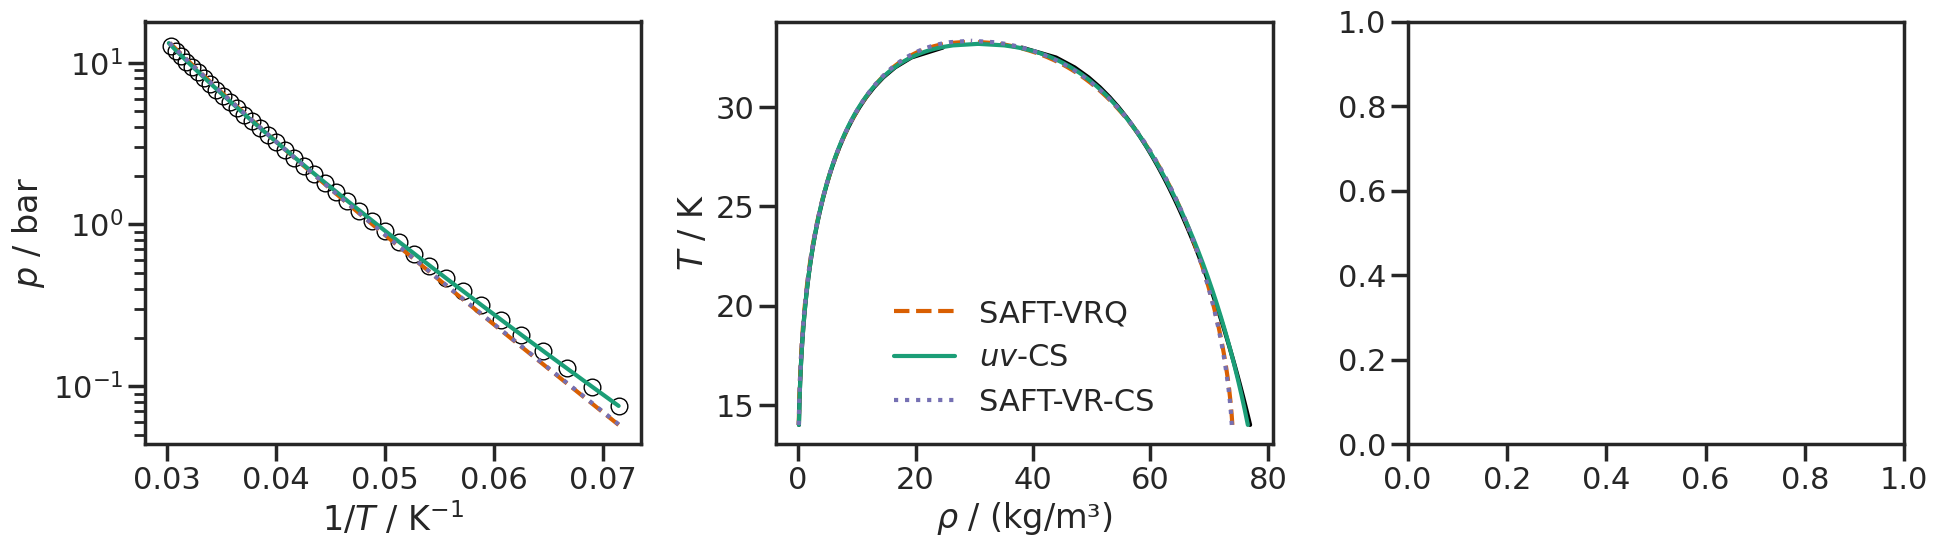

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Subplot 1: Vapor pressure vs Temperature  ---
axes[0].plot(1/ vle['Temperature (K)'], vle['Pressure (MPa)'] * (MEGA*PASCAL/BAR), 'o', mec='k', mfc='None')
axes[0].set_xlabel('$1/T$ / K$^{-1}$')
axes[0].set_ylabel('$p$ / bar')
#axes[0].set_title('Vapor Pressure')
axes[0].set_yscale('log')
axes[0].plot(1/np.array(df_vrq["temperature"]), np.array(df_vrq["pressure"]) * (PASCAL/BAR), '--', color=colors[1])
axes[0].plot(1/np.array(df_cs["temperature"]), np.array(df_cs["pressure"]) * (PASCAL/BAR),  color=colors[0])

axes[0].plot(1/np.array(df_vrcs["temperature"]), np.array(df_vrcs["pressure"]) * (PASCAL/BAR), ':', color=colors[2])

#axes[0].set_xlim(0.2, 0.45)

# --- Subplot 2: Density vs Temperature---
axes[1].plot(vle["Density (l, kg/m3)"], vle['Temperature (K)'], "k-")#, mec='k', mfc='None', ms=5)
axes[1].plot(vle["Density (v, kg/m3)"], vle['Temperature (K)'], 'k-') #'o', mec='k', mfc='None')
axes[1].set_xlabel('$\\rho$ / (kg/m³)')
axes[1].set_ylabel('$T$ / K')
#axes[1].set_ylim(2.5, 5.5)
axes[1].plot(df_vrq["mass density liquid"], df_vrq["temperature"],'--', color=colors[1], label="SAFT-VRQ")
axes[1].plot(df_vrq["mass density vapor"], df_vrq["temperature"], '--', color=colors[1] )


axes[1].plot(df_cs["mass density liquid"], df_cs["temperature"],'-', color=colors[0], label="$uv$-CS")
axes[1].plot(df_cs["mass density vapor"], df_cs["temperature"], '-', color=colors[0] )


axes[1].plot(df_vrcs["mass density liquid"], df_vrcs["temperature"],':', color=colors[2], label="SAFT-VR-CS")
axes[1].plot(df_vrcs["mass density vapor"], df_vrcs["temperature"], ':', color=colors[2] )


axes[1].legend(loc='best', frameon=False)

#axes[1].set_title('VLE Envelope')




        
#axes[1].plot(rho_c, tc, 'rx')
plt.tight_layout()
plt.show()